In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'




In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [5]:
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__

In [6]:
lwe_ds = GRACE().ds
sla = SLA(deg=1).da
sla0 = SLA(deg=0.25).da
dot_ds = DOT().ds

In [7]:
elevation_fine = GEBCO(coarsen_factor=1).ds
elevation = elevation_fine.coarsen(latitude=40,longitude=40).mean().elevation



In [8]:
mertz_local = [141,144,-68.5,-66.5]
adelie = [130,150,-68.5,-64]
east_antarctica = [70,170,-72,-60]
southern_ocean = [-180,180,-90,-50]

mertz_glacier = [144.25,-67.5]

In [9]:
# crop elevation
elevation_mertz = elevation_fine.sel(latitude = slice(-70,-65), longitude = slice(132,148)).elevation

In [10]:
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()


sha_ds_dot = StericHeight(ssh_ref='DOT',
                      ssh=dot_ds.dot,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

In [11]:
an = lambda da: da.groupby('time.year').mean()
yr = lambda da: [pd.Timestamp(y.item(),1,1) for y in an(da).year]

Adding row: Mertz Local
Adding row: Adelie Coast
Adding row: East Antarctica Shelf
Adding row: East Antarctica
Rendering..


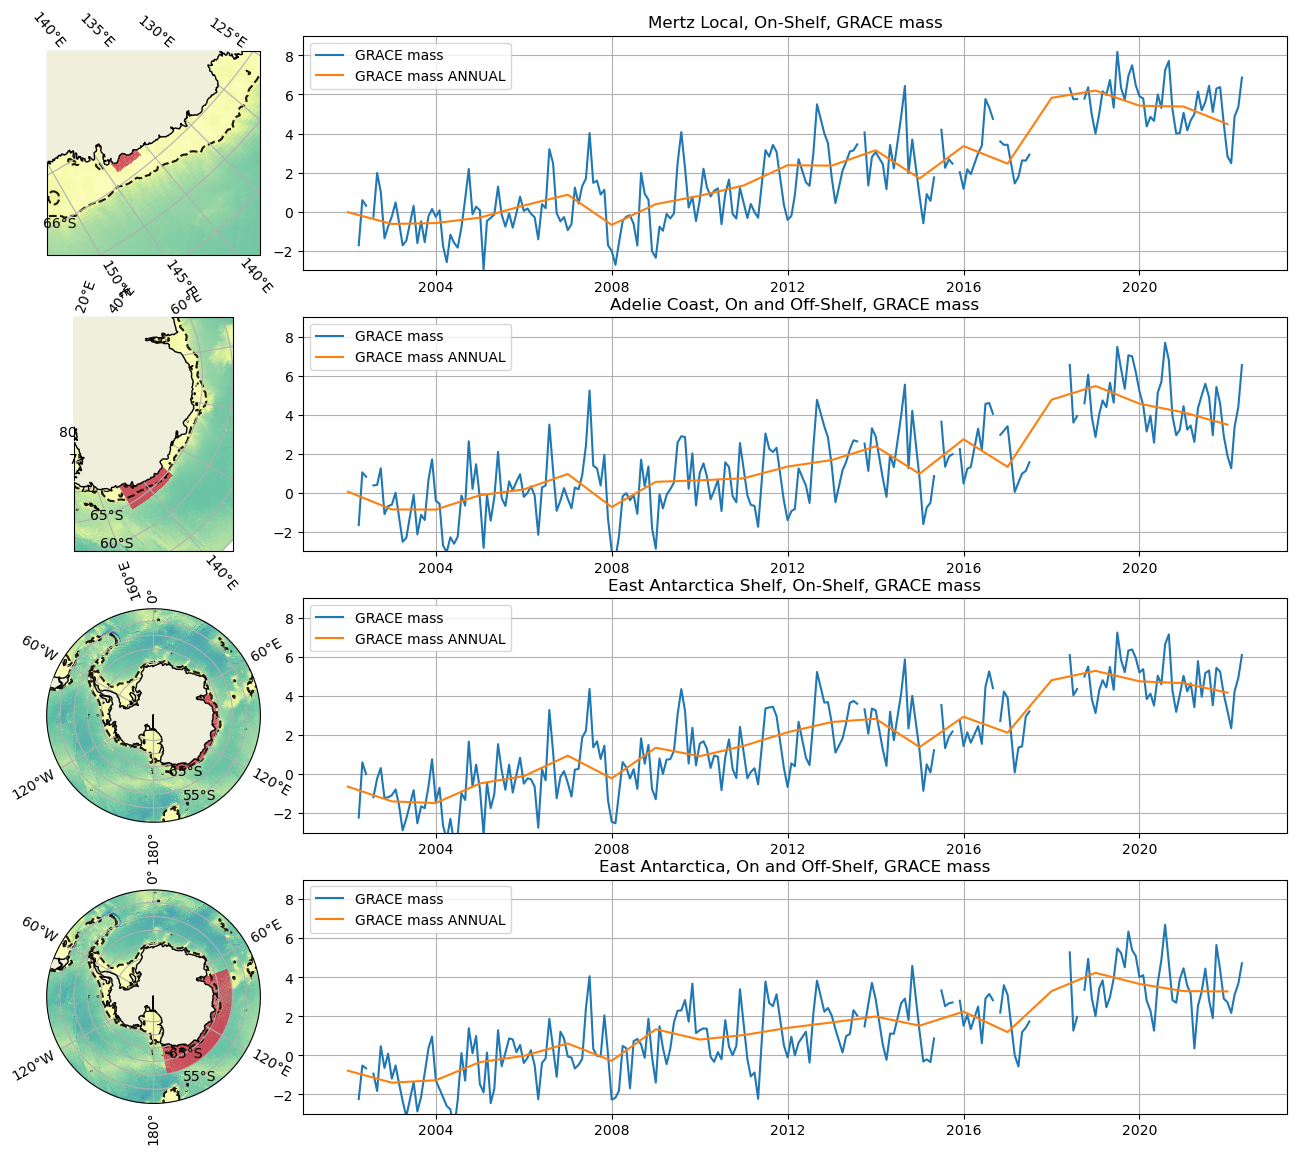

In [ ]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
var1 = sla
var2 = dot_ds.dota
var1name = 'SLA (1 degree)'
var2name = 'DOT (1 degree)'
title = 'SLA/DOT comparison'
fig = plt.figure(figsize=(16,14))
axs=[]

gs = fig.add_gridspec(4,5)

def add_row(n,title,extent,map_extent,shelf=False):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n, 0],projection=ccrs.SouthPolarStereo()))
    axs.append(fig.add_subplot(gs[n,1:5]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)
    region.plot_region(ax=axs[n*2],da=elevation,extent=map_extent)

    da = region.crop_da(var)
    ax = axs[(n*2)+1]

    ax.plot(da.time,da.mean(['latitude','longitude']),label=varname)
    ax.plot(yr(da),an(da).mean(['latitude','longitude']),label=varname + ' ANNUAL')

    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title+', '+shelf_str+'-Shelf, ' + varname)
    ax.legend(loc='best')
    ax.set_ylim([-3,9])
    ax.grid()

add_row(0,'Mertz Local',mertz_local,adelie,shelf=True)
add_row(1,'Adelie Coast',adelie,east_antarctica)
add_row(2,'East Antarctica Shelf',east_antarctica,southern_ocean,shelf=True)
add_row(3,'East Antarctica',east_antarctica,southern_ocean)
print('Rendering..')


Adding row: Mertz Local
Adding row: Adelie Coast
Adding row: East Antarctica Shelf
Adding row: East Antarctica
Rendering..


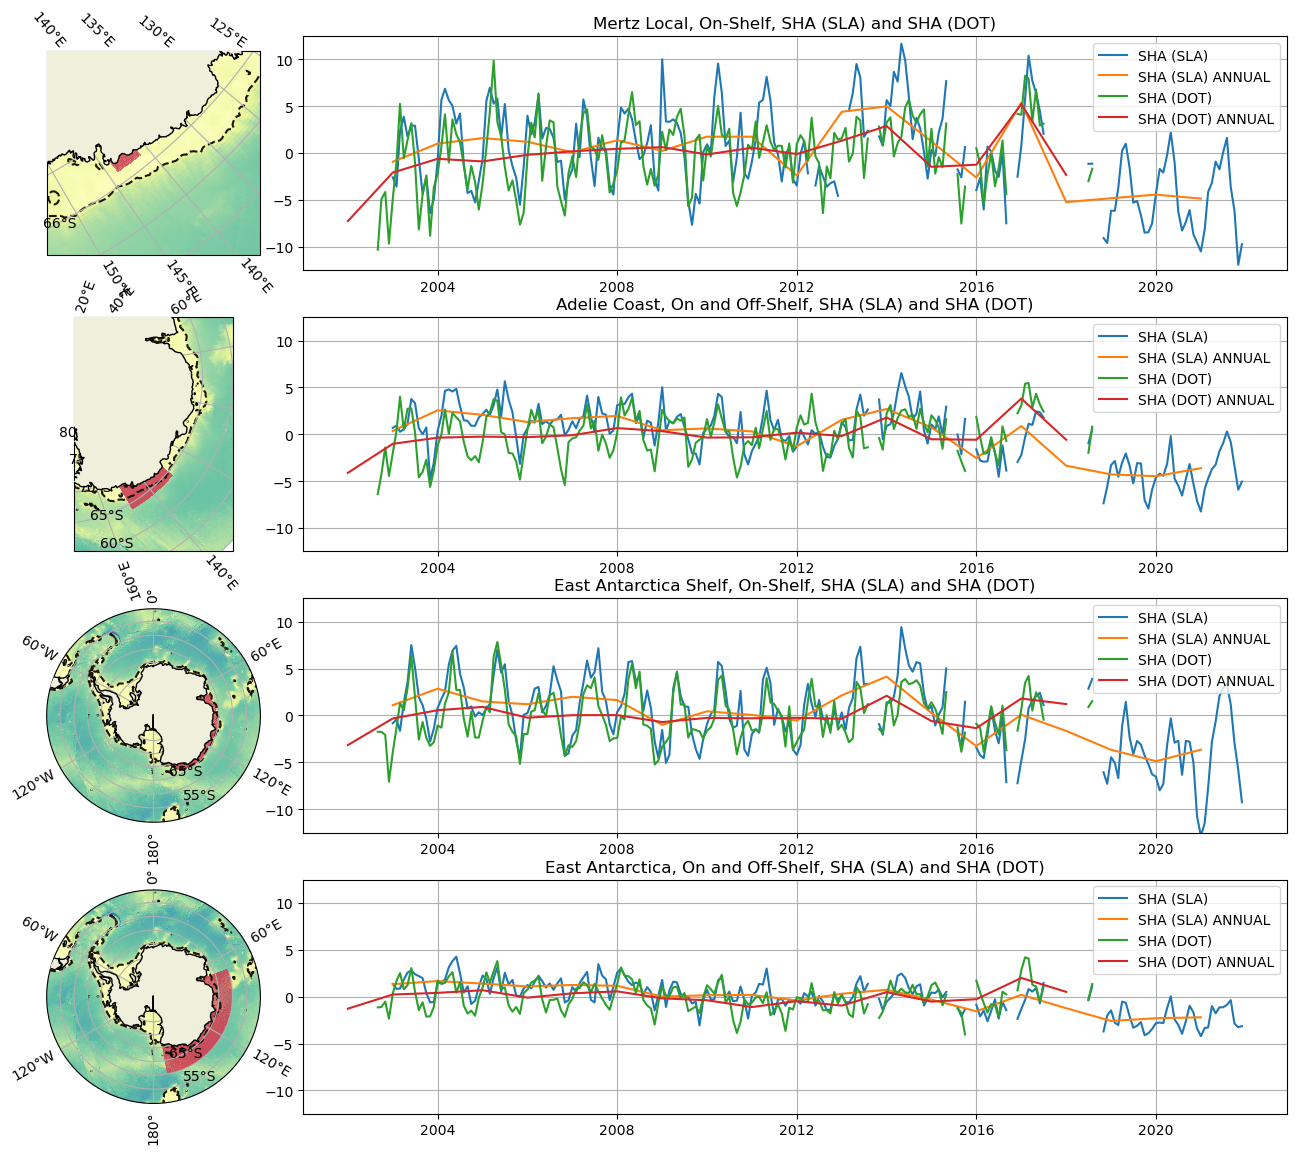

In [25]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
var1 = sha_ds_sla.sha
var2 = sha_ds_dot.sha
var1name = 'SHA (SLA)'
var2name = 'SHA (DOT)'
fig = plt.figure(figsize=(16,14))
axs=[]

gs = fig.add_gridspec(4,5)

def add_row(n,title,extent,map_extent,shelf=False):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n, 0],projection=ccrs.SouthPolarStereo()))
    axs.append(fig.add_subplot(gs[n,1:5]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)
    region.plot_region(ax=axs[n*2],da=elevation,extent=map_extent)

    da1 = region.crop_da(var1)
    da2 = region.crop_da(var2)
    ax = axs[(n*2)+1]

    ax.plot(da1.time,da1.mean(['latitude','longitude']),label=var1name)
    ax.plot(yr(da1),an(da1).mean(['latitude','longitude']),label=var1name + ' ANNUAL')

    ax.plot(da2.time,da2.mean(['latitude','longitude']),label=var2name)
    ax.plot(yr(da2),an(da2).mean(['latitude','longitude']),label=var2name + ' ANNUAL')


    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title+', '+shelf_str+'-Shelf, ' + var1name + ' and ' + var2name)
    ax.legend(loc='best')
    ax.set_ylim([-12.5,12.5])
    ax.grid()

add_row(0,'Mertz Local',mertz_local,adelie,shelf=True)
add_row(1,'Adelie Coast',adelie,east_antarctica)
add_row(2,'East Antarctica Shelf',east_antarctica,southern_ocean,shelf=True)
add_row(3,'East Antarctica',east_antarctica,southern_ocean)
print('Rendering..')


In [96]:
meop=MEOP(extent=data_extent)

NameError: name 'data_extent' is not defined

In [16]:
meop.load_profiles()

  0%|          | 0/79 [00:00<?, ?it/s]

100%|██████████| 79/79 [00:56<00:00,  1.40it/s]


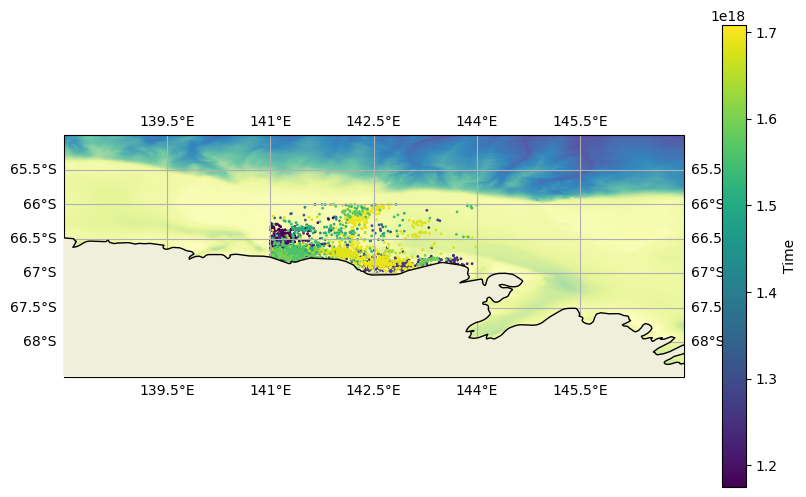

In [18]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.PlateCarree()})
pfns.sp(ax=ax,da=elevation,extent=map_extent)
im=ax.scatter(meop.df.longitude, meop.df.latitude, [1 for t in meop.df.index], meop.df.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')
